In [2]:
# If you are on google-colab you will need to first install sisl
!pip install sisl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 15.2 MB/s eta 0:00:00


In [6]:
  #We begin by importing numpy and pyplot
import sisl
import numpy as np
from helper_functions import *
import matplotlib.pyplot as plt
##This one is so that you can rotate the 3D images we will create
#%matplotlib ipympl  ## If you have ipympl installed you can uncomment this line

/content/helper_functions.py:98: SyntaxWarning: invalid escape sequence '\m'
  Rvec="\mathbf{{R}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:99: SyntaxWarning: invalid escape sequence '\m'
  kvec="\mathbf{{k}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:102: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {Rkvec}".format(Rkvec=Rkvec)
/content/helper_functions.py:105: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:108: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:112: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=Rdiff[dim])


Question 1

Perform a tight-binding calculation on a in infinite chain with t1 = −2 eV and t2 = −1
eV. Plot the dispersion relation as a function of the momentum k. Does the image change
if t2 = −2 eV and t1 = −1 eV? For convenience, you may set the on-site energy to zero
in the questions that follow and it is sufficient to consider only the one state per C atom
(the pz orbital). Feel free to make use of previous python notebooks for inspiration.

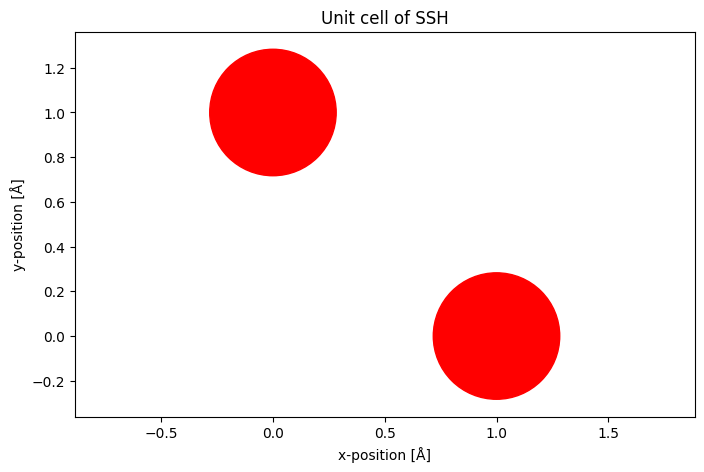

In [29]:
a=1 #distance between C atoms in Å
N = 50 #number of unit cells
k = 1 # dit moet anders want je wilt straks een functie van k maken...
lattice=sisl.Lattice([[3*a,0,0],[0,3*a,0],[0,0,3*a]]) ##We need to specify a lattice and give to SISL DEZE LATTICE KLOPT WS NIET


geomSSH = sisl.Geometry(xyz = [[0,1,0],[1,0,0]], lattice=lattice)

PlotGeometry(geomSSH,hold_show=True);
plt.title("Unit cell of SSH");





In [36]:
from IPython.core.application import BaseIPythonApplication

# create matrix
H_SSHinf = sisl.Hamiltonian(geomSSH) #is maar 2 bij 2 want twee atomen

# Assign hopping
t1 = -1.0 #eV
t2 = -2.0 #eV
alpha = 0 #eV (on site energy is zero (?))

H_SSHinf[1,0] = t1 + t2*np.exp(-1j*k*a)
H_SSHinf[0,1] = t1 + t2*np.exp(1j*k*a)

## print to test
#Numeric representation in Tex
print("Numerical matrix in Tex")
PrintMomentumRep(H_SSHinf,num_pf=True);


Numerical matrix in Tex


\begin{pmatrix}0 & -2.0806046117362795 \\ -2.0806046117362795 & 0\end{pmatrix}

Hamiltonian is hermitian!


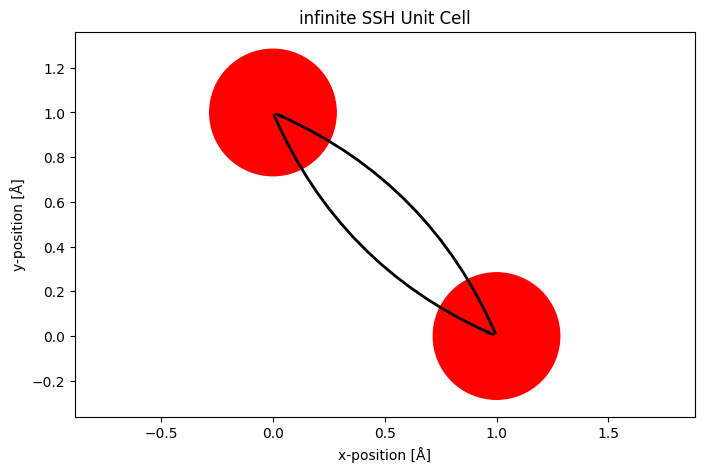

In [37]:
CheckHermiticity(H_SSHinf) ###This checks that the hamiltonian is hermitian
PlotHamTerms(H_SSHinf,hold_show=True);
plt.title("infinite SSH Unit Cell");

Ik denk dat dit nog niet klopt, want je ziet nu alleen de binding binnen de cel en niet die naar de andere cel...